# Snore vs Non‑Snore — Sample Visualizer (Waveform + Spectrogram + Audio)

This Colab notebook loads a few **snore** and **non‑snore** audio clips from your Drive dataset and visualizes them:
- Waveform (first 0.5 s)
- Full‑length spectrogram
- Inline audio player

> Expected dataset structure (same as your earlier notebooks):
>
> - `/content/drive/MyDrive/snore_data/Snoring Dataset/1` — snore WAVs  
> - `/content/drive/MyDrive/snore_data/Snoring Dataset/0` — non‑snore WAVs
>
> You can change paths or sample counts below.


In [ ]:
#@title Setup (Mount Drive & Install deps)
from google.colab import drive
drive.mount('/content/drive')
!pip install -q librosa soundfile matplotlib tqdm


Mounted at /content/drive


In [ ]:
#@title Paths & Parameters
import os, random

SNORE_DIR = "/content/drive/MyDrive/snore_data/Snoring Dataset/1"  #@param {type: "string"}
NON_DIR   = "/content/drive/MyDrive/snore_data/Snoring Dataset/0"  #@param {type: "string"}

N_SNORE    = 3  #@param {type:"slider", min:1, max:10, step:1}
N_NON      = 3  #@param {type:"slider", min:1, max:10, step:1}
SR         = 16000  #@param {type:"integer"}

assert os.path.isdir(SNORE_DIR), f"Missing folder: {SNORE_DIR}"
assert os.path.isdir(NON_DIR),   f"Missing folder: {NON_DIR}"

snore_files = [os.path.join(SNORE_DIR, f) for f in os.listdir(SNORE_DIR) if f.lower().endswith('.wav')]
non_files   = [os.path.join(NON_DIR,   f) for f in os.listdir(NON_DIR)   if f.lower().endswith('.wav')]

print(f"Found {len(snore_files)} snore files, {len(non_files)} non‑snore files.")
assert len(snore_files) > 0 and len(non_files) > 0, "No wavs found. Check your paths."


Found 500 snore files, 500 non‑snore files.


In [ ]:
#@title Utils: load, plot waveform & spectrogram, and play audio
import numpy as np
import librosa, librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from tqdm import tqdm

def load_mono(path, sr=16000):
    y, _ = librosa.load(path, sr=sr, mono=True)
    return y

def show_waveform(y, sr, title="Waveform (first 0.5 s)"):
    n = min(len(y), sr//2)
    plt.figure(figsize=(10,3))
    plt.plot(np.arange(n)/sr, y[:n])
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

def show_spectrogram(y, sr, title="Spectrogram"):
    # Power mel spectrogram for readability
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=64, power=2.0)
    S_db = librosa.power_to_db(S, ref=np.max)
    plt.figure(figsize=(8,3))
    librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='mel')
    plt.title(title)
    cbar = plt.colorbar()
    cbar.set_label("dB")
    plt.tight_layout()
    plt.show()

def show_clip(path, sr=16000, label=""):
    y = load_mono(path, sr=sr)
    base = os.path.basename(path)
    display(Audio(y, rate=sr))
    show_waveform(y, sr, title=f"{label} — {base} (first 0.5 s)")
    show_spectrogram(y, sr, title=f"{label} — {base} (full length)")



=== Snore Samples ===


  0%|          | 0/3 [00:00<?, ?it/s]

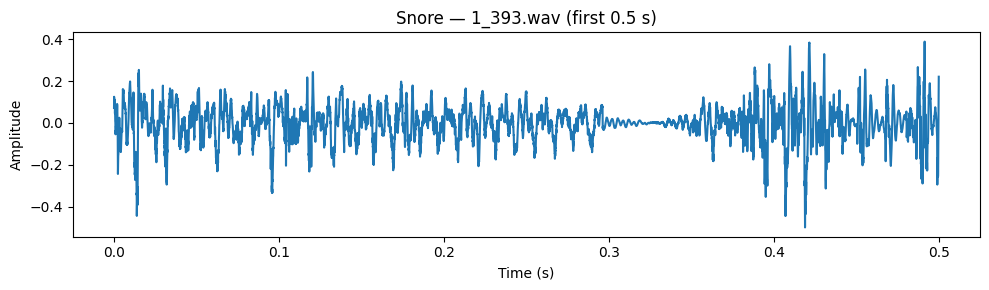

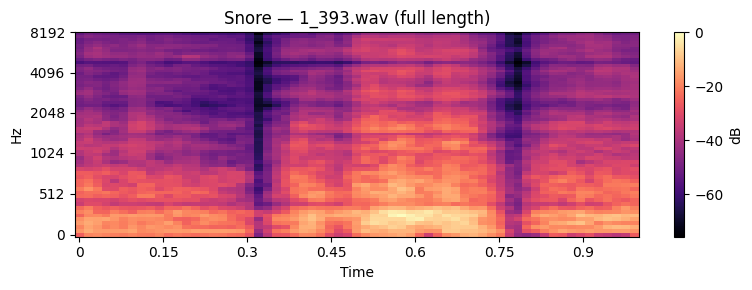

 33%|███▎      | 1/3 [00:25<00:51, 25.78s/it]

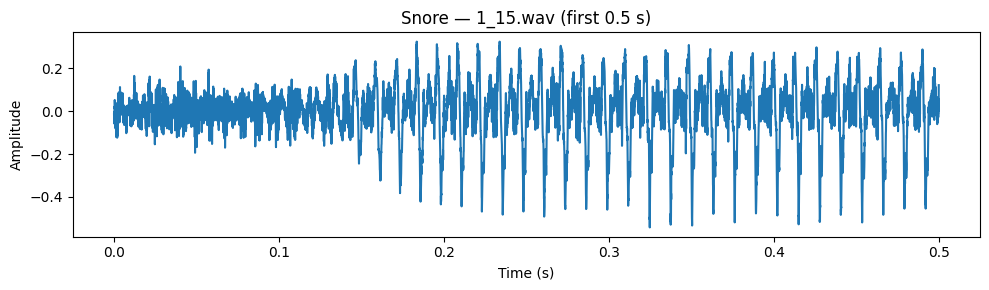

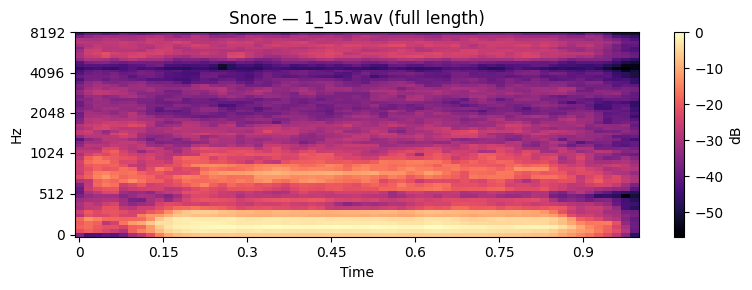

 67%|██████▋   | 2/3 [00:26<00:10, 11.00s/it]

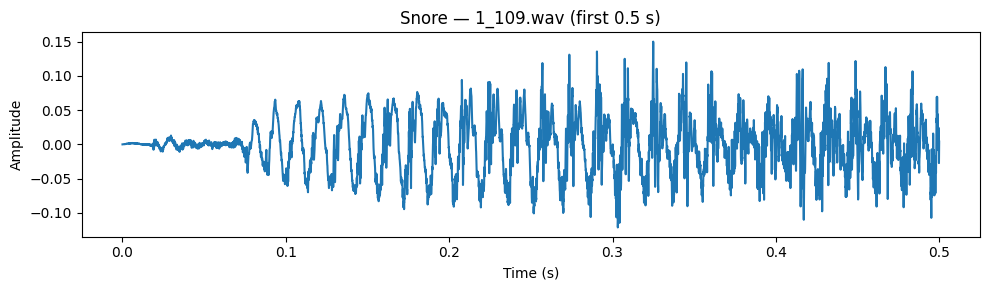

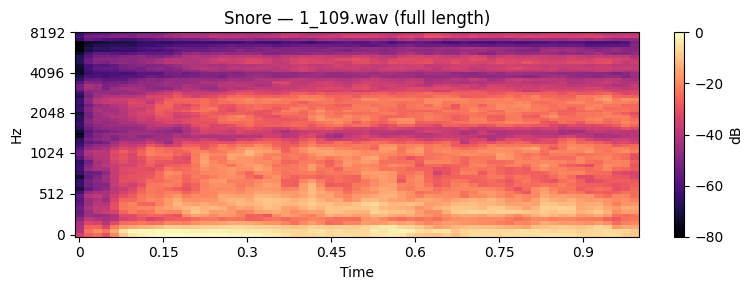

100%|██████████| 3/3 [00:27<00:00,  9.02s/it]



=== Non‑Snore Samples ===


  0%|          | 0/3 [00:00<?, ?it/s]

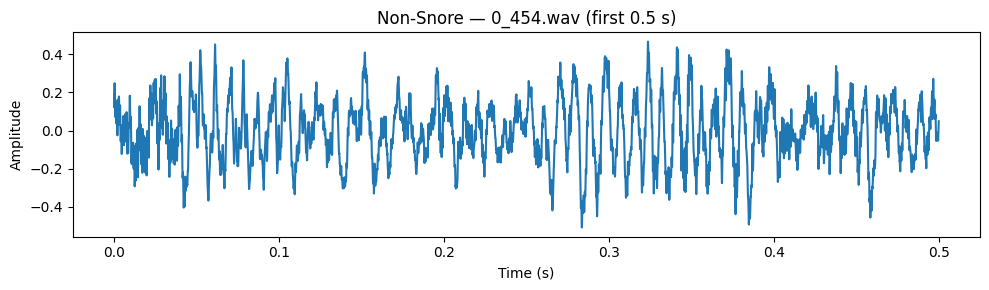

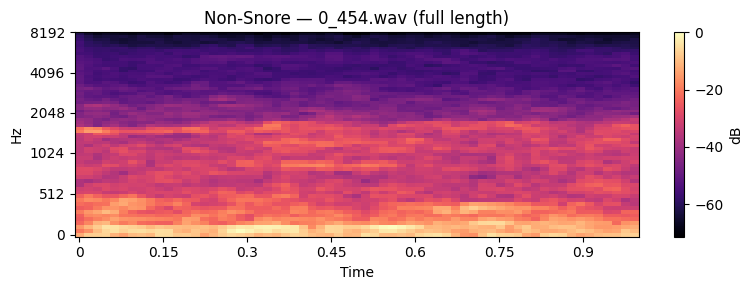

 33%|███▎      | 1/3 [00:00<00:01,  1.63it/s]

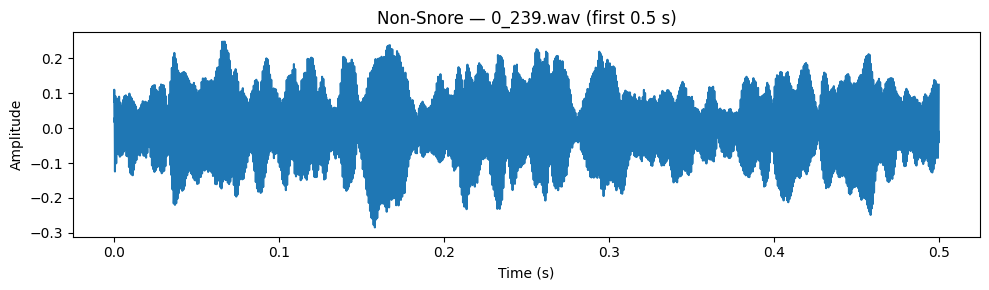

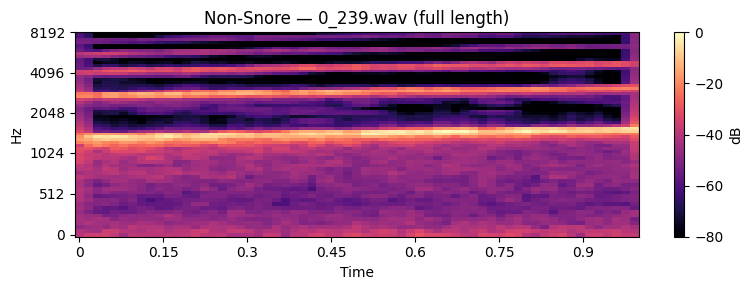

 67%|██████▋   | 2/3 [00:01<00:00,  1.41it/s]

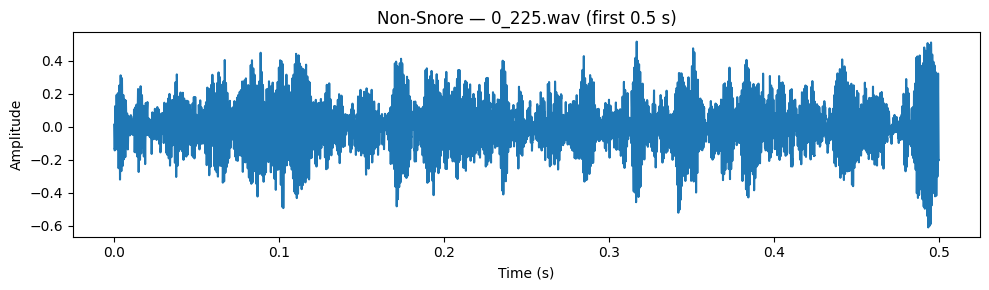

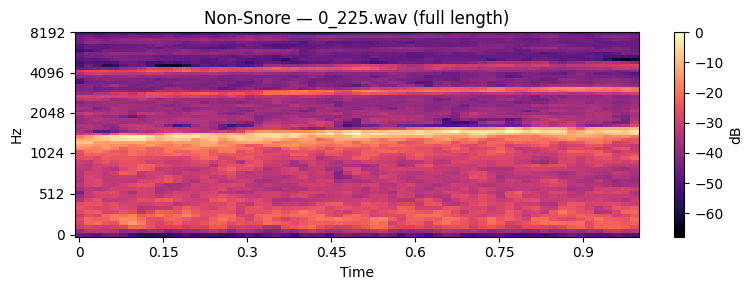

100%|██████████| 3/3 [00:02<00:00,  1.48it/s]


In [ ]:
#@title Visualize Random Samples
random.seed(42)
sampled_snore = random.sample(snore_files, k=min(N_SNORE, len(snore_files)))
sampled_non   = random.sample(non_files,   k=min(N_NON,   len(non_files)))

print("\n=== Snore Samples ===")
for p in tqdm(sampled_snore):
    show_clip(p, sr=SR, label="Snore")

print("\n=== Non‑Snore Samples ===")
for p in tqdm(sampled_non):
    show_clip(p, sr=SR, label="Non‑Snore")


SNR demo at 20 dB


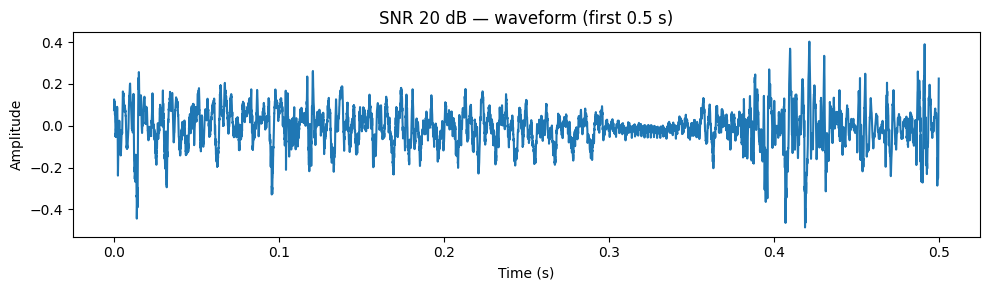

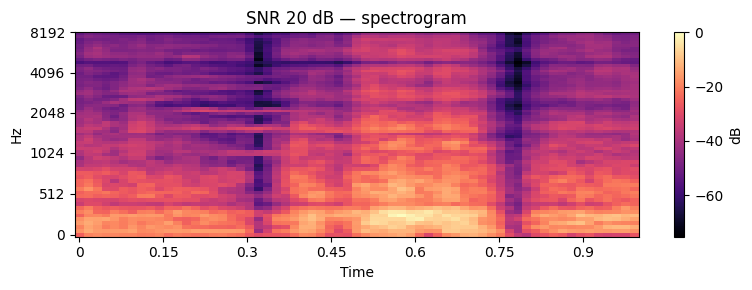

SNR demo at 10 dB


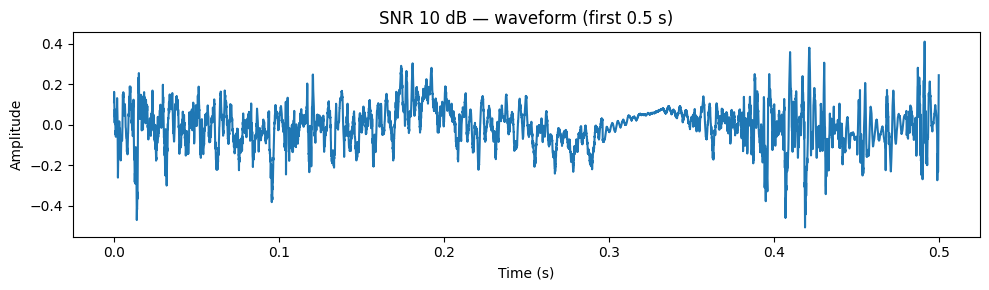

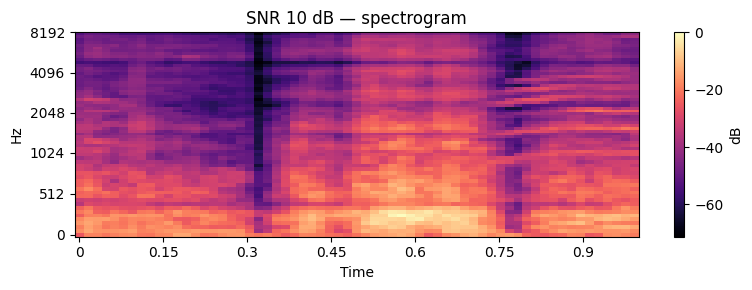

SNR demo at 5 dB


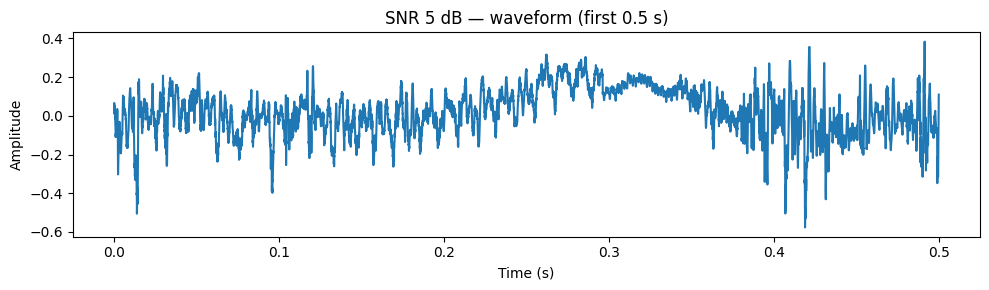

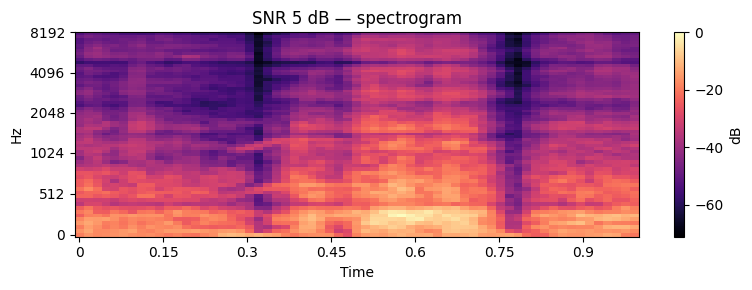

In [ ]:
import numpy as np
import librosa, os, random
from IPython.display import Audio, display

def match_noise_to_signal(noise, sig_len):
    """Return a noise vector exactly sig_len long.
       - If noise shorter: tile it.
       - If noise longer: take a random window to avoid repetition artifacts."""
    if len(noise) < sig_len:
        reps = int(np.ceil(sig_len / len(noise)))
        noise = np.tile(noise, reps)
    if len(noise) > sig_len:
        start = np.random.randint(0, len(noise) - sig_len + 1)
        noise = noise[start:start+sig_len]
    return noise

def mix_at_snr(signal, noise, snr_db):
    """Mix noise into signal at target SNR (dB)."""
    noise = match_noise_to_signal(noise, len(signal))
    eps = 1e-9
    rms_s = np.sqrt(np.mean(signal**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return signal + k * noise

# --- DEMO (uses your existing variables) ---
# Make sure SR is defined & consistent
SR = 16000

# 1) Pick a clip
demo_file = sampled_snore[0] if sampled_snore else snore_files[0]  # or choose from non_files
y = load_mono(demo_file, sr=SR)

# 2) Load a noise wav and ensure same SR + correct length
noise_wavs = [os.path.join(NOISE_DIR, f) for f in os.listdir(NOISE_DIR) if f.lower().endswith('.wav')]
n, _ = librosa.load(random.choice(noise_wavs), sr=SR, mono=True)

# 3) Mix at multiple SNRs and show
for snr in [20, 10, 5]:
    y_snr = mix_at_snr(y, n, snr_db=snr)
    print(f"SNR demo at {snr} dB")
    display(Audio(y_snr, rate=SR))
    show_waveform(y_snr, SR, title=f"SNR {snr} dB — waveform (first 0.5 s)")
    show_spectrogram(y_snr, SR, title=f"SNR {snr} dB — spectrogram")
